# 🛒 Vietnamese Graph RAG — Part 1: Embedding · NER · BiLSTM
**ĐH KHTN, ĐHQG-HCM — NLP Final Project**

Notebook này tái hiện **số liệu thật** dùng trong báo cáo:
- **TN1** — So sánh 4 phương pháp embedding (TF-IDF · Word2Vec · GloVe-SVD · PhoBERT) bằng Precision@k & MRR.
- **TN2** — Thống kê NER (underthesea PER/LOC/ORG + gazetteer brand).
- **TN2b** — BiLSTM phân loại đa nhãn aspect (Lec05), báo cáo micro-F1.

> Chạy được cả trên Kaggle lẫn local. *Word2Vec tự train skip-gram + negative-sampling bằng PyTorch* (không cần gensim).

## ⚙️ Bootstrap (Kaggle / local tự nhận diện)
Trên **Kaggle**: cài thư viện + `git clone` repo (code + data) + build artifacts nếu thiếu (cần **GPU T4**).
Trên **local**: cell này bỏ qua (đã có repo). Không cần sửa gì khi Run All.

In [1]:
import os, subprocess
ON_KAGGLE = os.path.exists('/kaggle')
REPO = 'https://github.com/lphhien112-gif/vietnamese-graph-rag.git'
if ON_KAGGLE:
    subprocess.run('pip install -q underthesea transformers scikit-learn scipy networkx matplotlib', shell=True)
    if not os.path.isdir('/kaggle/working/vietnamese-graph-rag'):
        subprocess.run(f'cd /kaggle/working && git clone -q {REPO}', shell=True)
    os.chdir('/kaggle/working/vietnamese-graph-rag')
    if not os.path.exists('artifacts/doc_vectors.npy'):
        print('Build index (PhoBERT encode ~10.9k review, cần GPU)...'); subprocess.run('python -m vngraphrag.cli.build_index', shell=True)
print('Môi trường:', 'Kaggle' if ON_KAGGLE else 'local')

Môi trường: local


## 0. Thiết lập — import package & dữ liệu

In [2]:
import sys, os, json, re
from pathlib import Path
import numpy as np

# Cho phép import package src/vngraphrag (local repo). Trên Kaggle: thay bằng path tương ứng.
ROOT = Path.cwd()
ROOT = ROOT if (ROOT / 'src').exists() else ROOT.parent
os.chdir(ROOT)                       # path tương đối (artifacts/, data/raw) trỏ đúng repo root
sys.path.insert(0, str(ROOT / 'src'))

from vngraphrag.config import Config
from vngraphrag.core import (load_visfd, load_shopee, build_records, ASPECTS,
                             detect_brand, preprocess_vietnamese)
cfg = Config.load(ROOT / 'config.yaml')
print('ASPECTS (10):', ASPECTS)

ASPECTS (10): ['SCREEN', 'CAMERA', 'BATTERY', 'PERFORMANCE', 'STORAGE', 'DESIGN', 'PRICE', 'GENERAL', 'FEATURES', 'SER&ACC']


## 1. Load corpus từ index đã build (nguồn canonical)
Lấy `corpus`/`gold` trực tiếp từ `index.records` để **khớp đúng thứ tự vector PhoBERT** đã encode
(`artifacts/doc_vectors.npy`) — đảm bảo cả 4 phương pháp embedding so sánh trên *cùng* tập tài liệu.

In [3]:
from vngraphrag.core import DocumentIndex
index = DocumentIndex.load(cfg.artifacts_dir, cfg.embedding_model)
assert index is not None, 'Chưa có index — chạy: python -m vngraphrag.cli.build_index'
corpus = [r['raw'] for r in index.records]
gold   = [set(r['gold']) for r in index.records]
n_uit  = sum(1 for r in index.records if r['source'] == 'UIT-ViSFD')
print(f'corpus hợp nhất: {len(corpus)} review')
print(f'  -> {n_uit} review UIT có nhãn vàng + {len(corpus)-n_uit} review Shopee (nhiễu)')

corpus hợp nhất: 10923 review
  -> 7786 review UIT có nhãn vàng + 3137 review Shopee (nhiễu)


## 2. TN1 — So sánh 4 phương pháp Embedding
Cùng 8 truy vấn (mỗi truy vấn nhắm 1 aspect), pool xếp hạng = toàn corpus 10.923 review
(7.786 UIT có gold + 3.137 Shopee nhiễu). Relevance = nhãn vàng chứa aspect. Báo cáo P@5/P@10/MRR.

In [4]:
EVAL_QUERIES = [
    ("camera chụp ảnh đẹp không", "CAMERA"), ("pin trâu dùng lâu không", "BATTERY"),
    ("màn hình hiển thị sắc nét", "SCREEN"), ("máy chạy mượt hiệu năng", "PERFORMANCE"),
    ("giá hợp lý hay đắt", "PRICE"),         ("thiết kế đẹp cầm thoải mái", "DESIGN"),
    ("loa âm thanh tính năng", "FEATURES"),  ("nhân viên tư vấn bảo hành dịch vụ", "SER&ACC"),
]
_TOK = re.compile(r"[a-zà-ỹ0-9]+", re.IGNORECASE)
def tok(s): return _TOK.findall(s.lower())
def l2(m):
    n = np.linalg.norm(m, axis=1, keepdims=True); return m / np.clip(n, 1e-9, None)
def p_at_k(order, asp, k): return sum(1 for i in order[:k] if asp in gold[i]) / k
def mrr(order, asp):
    for r, i in enumerate(order, 1):
        if asp in gold[i]: return 1.0 / r
    return 0.0
def score(D, Q):
    p5=p10=mr=0.0
    for (_, asp), qv in zip(EVAL_QUERIES, Q):
        order = np.argsort(D @ qv)[::-1]
        p5 += p_at_k(order, asp, 5); p10 += p_at_k(order, asp, 10); mr += mrr(order, asp)
    n=len(EVAL_QUERIES); return {"P@5":round(p5/n,4),"P@10":round(p10/n,4),"MRR":round(mr/n,4)}

### 2.1 TF-IDF — *Lec02* (baseline thưa, thống kê)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(tokenizer=tok, token_pattern=None, min_df=2, max_features=20000)
Dt = l2(np.asarray(vec.fit_transform(corpus).todense())).astype('float32')
Qt = l2(np.asarray(vec.transform([q for q,_ in EVAL_QUERIES]).todense())).astype('float32')
res_tfidf = score(Dt, Qt); print('TF-IDF:', res_tfidf)

TF-IDF: {'P@5': 0.8, 'P@10': 0.7625, 'MRR': 0.8073}


### 2.2 Word2Vec — *Lec02* (skip-gram + negative sampling, PyTorch — không cần gensim)

In [6]:
import torch
from collections import Counter
def train_word2vec(dim=100, window=5, neg=5, epochs=3, vocab_size=8000):
    toks = [tok(c) for c in corpus]
    freq = Counter(w for t in toks for w in t)
    itos = [w for w,c in freq.most_common(vocab_size) if c>=2]; stoi={w:i for i,w in enumerate(itos)}
    ctr, ctx = [], []
    for t in toks:
        ids=[stoi[w] for w in t if w in stoi]
        for a in range(len(ids)):
            for b in range(max(0,a-window), min(len(ids),a+window+1)):
                if a!=b: ctr.append(ids[a]); ctx.append(ids[b])
    ctr=torch.tensor(ctr); ctx=torch.tensor(ctx)
    f=np.array([freq[w] for w in itos],dtype='float64')**0.75; negp=torch.tensor(f/f.sum())
    torch.manual_seed(42)
    Win=torch.nn.Embedding(len(itos),dim); Wout=torch.nn.Embedding(len(itos),dim)
    torch.nn.init.normal_(Win.weight,std=0.1); torch.nn.init.normal_(Wout.weight,std=0.1)
    opt=torch.optim.Adam(list(Win.parameters())+list(Wout.parameters()),lr=2e-3); bs=4096; N=len(ctr)
    for ep in range(epochs):
        perm=torch.randperm(N); tot=0.0
        for i in range(0,N,bs):
            idx=perm[i:i+bs]; c=ctr[idx]; o=ctx[idx]
            n=torch.multinomial(negp,len(idx)*neg,replacement=True).view(len(idx),neg)
            vc=Win(c); vo=Wout(o); vn=Wout(n)
            pos=torch.nn.functional.logsigmoid((vc*vo).sum(1))
            ng=torch.nn.functional.logsigmoid(-(vn*vc.unsqueeze(1)).sum(2)).sum(1)
            loss=-(pos+ng).mean(); opt.zero_grad(); loss.backward(); opt.step(); tot+=loss.item()*len(idx)
        print(f'  epoch {ep+1}/{epochs} loss={tot/N:.4f}')
    W=l2(Win.weight.detach().numpy().astype('float32'))
    def emb(ws):
        ids=[stoi[w] for w in ws if w in stoi]; return W[ids].mean(0) if ids else np.zeros(dim,'float32')
    return emb, toks
emb_w2v, toks_all = train_word2vec()
Dw=l2(np.vstack([emb_w2v(t) for t in toks_all])); Qw=l2(np.vstack([emb_w2v(tok(q)) for q,_ in EVAL_QUERIES]))
res_w2v=score(Dw,Qw); print('Word2Vec:', res_w2v)

  epoch 1/3 loss=2.7010


  epoch 2/3 loss=2.3768


  epoch 3/3 loss=2.3255


Word2Vec: {'P@5': 0.825, 'P@10': 0.8375, 'MRR': 0.8767}


### 2.3 GloVe-SVD — *Lec02* (PPMI co-occurrence → TruncatedSVD)

In [7]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
def glove_svd(dim=100, window=5, vocab_size=6000):
    freq=Counter(w for t in toks_all for w in t)
    itos=[w for w,_ in freq.most_common(vocab_size)]; stoi={w:i for i,w in enumerate(itos)}; V=len(itos)
    co=Counter()
    for t in toks_all:
        ids=[stoi[w] for w in t if w in stoi]
        for a in range(len(ids)):
            for b in range(max(0,a-window),min(len(ids),a+window+1)):
                if a!=b: co[(ids[a],ids[b])]+=1
    rows,cols,vals=zip(*[(i,j,c) for (i,j),c in co.items()])
    C=csr_matrix((vals,(rows,cols)),shape=(V,V),dtype='float64'); tot=C.sum()
    rs=np.asarray(C.sum(1)).ravel(); cs=np.asarray(C.sum(0)).ravel(); C=C.tocoo()
    pmi=np.log((C.data*tot)/(rs[C.row]*cs[C.col])+1e-12); pmi[pmi<0]=0.0
    P=csr_matrix((pmi,(C.row,C.col)),shape=(V,V))
    W=l2(TruncatedSVD(n_components=dim,random_state=42).fit_transform(P)).astype('float32')
    def emb(ws):
        ids=[stoi[w] for w in ws if w in stoi]; return W[ids].mean(0) if ids else np.zeros(dim,'float32')
    return emb
emb_g=glove_svd()
Dg=l2(np.vstack([emb_g(t) for t in toks_all])); Qg=l2(np.vstack([emb_g(tok(q)) for q,_ in EVAL_QUERIES]))
res_glove=score(Dg,Qg); print('GloVe-SVD:', res_glove)

GloVe-SVD: {'P@5': 0.825, 'P@10': 0.8375, 'MRR': 0.8767}


### 2.4 PhoBERT — *Lec06 Transformer* (mean-pool, dùng vector đã encode)

In [8]:
from vngraphrag.core import PhoBERTEncoder
Dp = l2(index.vectors.astype('float32'))   # vector align với corpus ở Mục 1
enc = PhoBERTEncoder(cfg.embedding_model, cfg.max_seq_len)
Qp = l2(enc.encode_mean([q for q,_ in EVAL_QUERIES]).astype('float32'))
res_phobert = score(Dp, Qp); print('PhoBERT:', res_phobert)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PhoBERT: {'P@5': 0.8, 'P@10': 0.775, 'MRR': 0.8333}


### 2.5 ⭐ Bảng so sánh + biểu đồ

,P@5,P@10,MRR
TF-IDF,0.800,0.7625,0.8073
Word2Vec,0.825,0.8375,0.8767
GloVe-SVD,0.825,0.8375,0.8767
PhoBERT,0.800,0.7750,0.8333


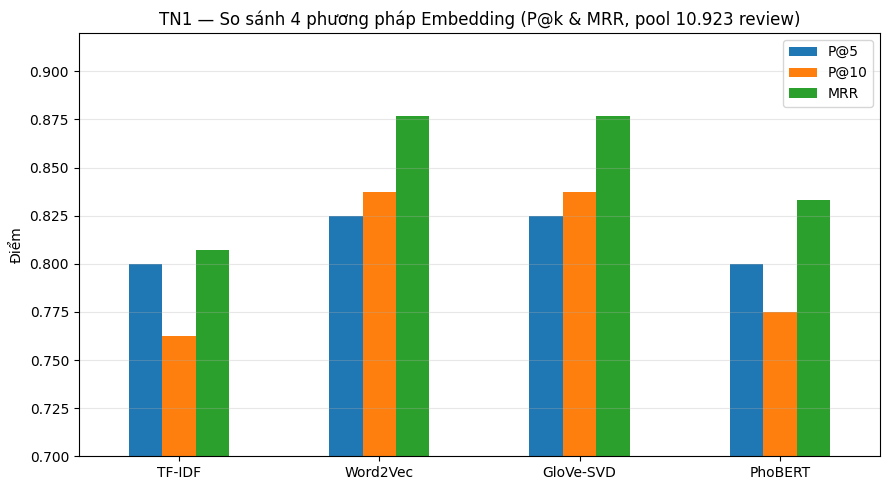

In [9]:
import pandas as pd, matplotlib.pyplot as plt
results = {'TF-IDF':res_tfidf,'Word2Vec':res_w2v,'GloVe-SVD':res_glove,'PhoBERT':res_phobert}
metrics_df = pd.DataFrame(results).T[['P@5','P@10','MRR']]
display(metrics_df)
ax = metrics_df.plot(kind='bar', figsize=(9,5), ylim=(0.7,0.92), rot=0)
ax.set_title('TN1 — So sánh 4 phương pháp Embedding (P@k & MRR, pool 10.923 review)')
ax.set_ylabel('Điểm'); ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## 2.6 *Lec03* — Subword / BPE tokenization (xử lý từ hiếm/OOV)
PhoBERT dùng **Byte-Pair Encoding (BPE)** trên dữ liệu tiếng Việt đã tách từ. Cell dưới
demo trực tiếp: tách văn bản thành **mảnh subword** (token `@@` là nối tiếp), kể cả từ
hiếm/sai chính tả vẫn biểu diễn được qua tổ hợp subword — khắc phục OOV của TF-IDF/Word2Vec.

In [10]:
from transformers import AutoTokenizer
bpe = AutoTokenizer.from_pretrained(cfg.embedding_model)
samples = ["camera chụp đêm", "pinnn tụttt nhanhhh", "điện_thoại chống_nước siêu bền"]
for s in samples:
    toks = bpe.tokenize(s)
    print(f'{s!r:45} -> {len(toks)} subword: {toks}')
# minh hoạ OOV: 1 từ bịa vẫn tách được thành subword (không bị <unk> như từ vựng cố định)
oov = "xuyzzphone"; print(f'\nTừ OOV {oov!r} -> {bpe.tokenize(oov)}  (không mất thông tin)')
n_vocab = bpe.vocab_size; print(f'Kích thước từ vựng BPE của PhoBERT: {n_vocab:,} subword')

'camera chụp đêm'                             -> 3 subword: ['camera', 'chụp', 'đêm']
'pinnn tụttt nhanhhh'                         -> 8 subword: ['pin@@', 'nn', 'tụ@@', 't@@', 'tt', 'nhanh@@', 'h@@', 'h']
'điện_thoại chống_nước siêu bền'              -> 5 subword: ['điện_thoại', 'chống_@@', 'nước', 'siêu', 'bền']

Từ OOV 'xuyzzphone' -> ['xuy@@', 'zz@@', 'phone']  (không mất thông tin)
Kích thước từ vựng BPE của PhoBERT: 64,000 subword


## 3. TN2 — NER (underthesea PER/LOC/ORG) + gazetteer brand
Trên 800 review mẫu. Không có nhãn vàng NER cho domain → báo cáo theo số lượng & độ phủ.

In [11]:
from underthesea import ner
SAMPLE=800; step=max(1,len(corpus)//SAMPLE)
sample=[corpus[i] for i in range(0,len(corpus),step)][:SAMPLE]
type_counts=Counter(); spans=Counter(); docs_ent=0; brand_counts=Counter(); docs_brand=0
for text in sample:
    try: tags=ner(text)
    except Exception: tags=[]
    prev=None; has=False
    for tup in tags:
        tag=str(tup[-1]) if isinstance(tup,(list,tuple)) else ''
        t=tag.split('-',1)[1] if '-' in tag else None
        if t:
            type_counts[t]+=1; has=True
            if not (tag.startswith('I-') and prev==t): spans[t]+=1
            prev=t
        else: prev=None
    docs_ent+=int(has)
    b=detect_brand(text)
    if b!='Unknown': brand_counts[b]+=1; docs_brand+=1
print('SPAN thực thể:', dict(spans.most_common()))
print(f'review có >=1 thực thể: {docs_ent}/{len(sample)}')
print(f'review nhận diện brand (gazetteer): {docs_brand}/{len(sample)}')
print('Top brand:', dict(brand_counts.most_common(6)))

SPAN thực thể: {'PER': 292, 'LOC': 282, 'ORG': 6, 'MISC': 1}
review có >=1 thực thể: 387/800
review nhận diện brand (gazetteer): 72/800
Top brand: {'Samsung': 23, 'Apple': 16, 'Xiaomi': 7, 'VSmart': 7, 'Nokia': 6, 'OPPO': 5}


## 4. TN2b — BiLSTM phân loại đa nhãn aspect (*Lec05*)
Embedding 100, hidden 128, hai chiều; BCEWithLogitsLoss; báo cáo micro-F1 trên tập dev.

In [12]:
import torch, torch.nn as nn
train = load_visfd(cfg.data_dir if Path(cfg.data_dir).exists() else ROOT/'data/raw', 'Train.csv')
dev   = load_visfd(cfg.data_dir if Path(cfg.data_dir).exists() else ROOT/'data/raw', 'Dev.csv')
train['clean']=train['comment'].map(preprocess_vietnamese); dev['clean']=dev['comment'].map(preprocess_vietnamese)
MAXLEN,EMB,HID=40,100,128
freq=Counter(w for t in train['clean'] for w in t.split())
itos=['<pad>','<unk>']+[w for w,_ in freq.most_common(8000)]; stoi={w:i for i,w in enumerate(itos)}
def enc_ids(t): ids=[stoi.get(w,1) for w in t.split()[:MAXLEN]]; return ids+[0]*(MAXLEN-len(ids))
def multihot(asps):
    v=torch.zeros(len(ASPECTS))
    for a in asps:
        if a in ASPECTS: v[ASPECTS.index(a)]=1.0
    return v
xtr=torch.tensor([enc_ids(t) for t in train['clean']]); ytr=torch.stack([multihot(a) for a in train['aspects']])
xdv=torch.tensor([enc_ids(t) for t in dev['clean']]);   ydv=torch.stack([multihot(a) for a in dev['aspects']])
class BiLSTMAspect(nn.Module):
    def __init__(s):
        super().__init__(); s.emb=nn.Embedding(len(itos),EMB,padding_idx=0)
        s.lstm=nn.LSTM(EMB,HID,batch_first=True,bidirectional=True); s.fc=nn.Linear(HID*2,len(ASPECTS))
    def forward(s,x): o,_=s.lstm(s.emb(x)); return s.fc(o.mean(1))
torch.manual_seed(0); model=BiLSTMAspect(); opt=torch.optim.Adam(model.parameters(),lr=1e-3); lossf=nn.BCEWithLogitsLoss()
for ep in range(8):
    model.train(); perm=torch.randperm(len(xtr))
    for i in range(0,len(xtr),128):
        idx=perm[i:i+128]; opt.zero_grad(); lossf(model(xtr[idx]),ytr[idx]).backward(); opt.step()
    model.eval()
    with torch.no_grad(): pred=(torch.sigmoid(model(xdv))>0.5).bool()
    g=ydv.bool(); tp=(g&pred).sum().item(); fp=(pred&~g).sum().item(); fn=(g&~pred).sum().item()
    prec=tp/(tp+fp) if tp+fp else 0; rec=tp/(tp+fn) if tp+fn else 0
    f1=2*prec*rec/(prec+rec) if prec+rec else 0
    print(f'epoch {ep+1}/8 — dev micro-F1 = {f1:.4f}')
print(f'\n==> BiLSTM dev micro-F1 = {f1:.4f}')

epoch 1/8 — dev micro-F1 = 0.4688


epoch 2/8 — dev micro-F1 = 0.6254


epoch 3/8 — dev micro-F1 = 0.7002


epoch 4/8 — dev micro-F1 = 0.7412


epoch 5/8 — dev micro-F1 = 0.7621


epoch 6/8 — dev micro-F1 = 0.7859


epoch 7/8 — dev micro-F1 = 0.7842


epoch 8/8 — dev micro-F1 = 0.7966

==> BiLSTM dev micro-F1 = 0.7966


## 5. Lưu kết quả cho báo cáo

In [13]:
out = {'embedding': results,
       'bpe_vocab_size': int(n_vocab),
       'ner': {'spans': dict(spans), 'docs_with_entity': docs_ent,
               'docs_with_brand': docs_brand, 'brands': dict(brand_counts.most_common())},
       'bilstm_micro_f1': round(f1, 4)}
Path(ROOT/'artifacts').mkdir(exist_ok=True)
(ROOT/'artifacts'/'results_part1.json').write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding='utf-8')
print('Đã lưu artifacts/results_part1.json'); print(json.dumps(out, ensure_ascii=False, indent=2))

Đã lưu artifacts/results_part1.json
{
  "embedding": {
    "TF-IDF": {
      "P@5": 0.8,
      "P@10": 0.7625,
      "MRR": 0.8073
    },
    "Word2Vec": {
      "P@5": 0.825,
      "P@10": 0.8375,
      "MRR": 0.8767
    },
    "GloVe-SVD": {
      "P@5": 0.825,
      "P@10": 0.8375,
      "MRR": 0.8767
    },
    "PhoBERT": {
      "P@5": 0.8,
      "P@10": 0.775,
      "MRR": 0.8333
    }
  },
  "bpe_vocab_size": 64000,
  "ner": {
    "spans": {
      "PER": 292,
      "LOC": 282,
      "ORG": 6,
      "MISC": 1
    },
    "docs_with_entity": 387,
    "docs_with_brand": 72,
    "brands": {
      "Samsung": 23,
      "Apple": 16,
      "Xiaomi": 7,
      "VSmart": 7,
      "Nokia": 6,
      "OPPO": 5,
      "Vivo": 4,
      "Realme": 3,
      "Asus": 1
    }
  },
  "bilstm_micro_f1": 0.7966
}
